In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor

In [2]:
train = pd.read_csv("../data/raw/train.csv")
features = pd.read_csv("../data/raw/features.csv")
stores = pd.read_csv("../data/raw/stores.csv")

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## Data Integration Strategy

We could train the model using only the `train.csv` dataset; however, this approach would ignore several critical external factors that influence sales behavior.

Key features such as:
- Temperature  
- Fuel Price  
- Consumer Price Index (CPI)  
- Unemployment Rate  
- Promotional Markdowns  

are not present in the training dataset alone but are essential for capturing real-world demand dynamics.

Ignoring these variables would result in a model that lacks contextual awareness and performs poorly in changing market conditions.

### Final Approach

To build a more robust and realistic model, we combine all three datasets:

- `train.csv` → Core sales data  
- `features.csv` → Economic and environmental factors  
- `stores.csv` → Store-level metadata  

Although this introduces additional complexity in terms of data merging and preprocessing (handling missing values, aligning keys, feature engineering), it significantly improves the model’s ability to learn meaningful patterns.

### Conclusion

Combining all datasets enables the model to:
- Capture market trends  
- Incorporate external influencing factors  
- Better generalize to real-world scenarios  

This tradeoff increased complexity for improved performance and realism is both necessary and justified in a production-grade ML system.

In [6]:
# PREPROCESSING 

#MERGING
df = pd.merge(train,features, on =["Store","Date"], how = "left")
df = pd.merge(df,stores,on=["Store"],how ="left")


In [7]:

# FIX DATE + SORT


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # fix dtype

df = df.dropna(subset=['Date'])  # remove invalid rows

df = df.sort_values(['Store','Dept','Date'])  # required for lag/rolling

print(df['Date'].dtype)

datetime64[ns]


In [8]:

# MARKDOWN HANDLING


markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)

df['total_markdown'] = df[markdown_cols].sum(axis=1)
df['has_promo'] = (df['total_markdown'] > 0).astype(int)

df = df.drop(columns=markdown_cols)

In [9]:

# DATA VALIDATION


# duplicates check
dup = df.duplicated(subset=['Store','Dept','Date']).sum()
print("duplicates:", dup)

# monotonic check
print("time sorted:",
      df.groupby(['Store','Dept'])['Date'].is_monotonic_increasing.all())

duplicates: 0
time sorted: True


In [10]:

# LAG FEATURES

df['lag_1'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['lag_7'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(7)

In [ ]:

# ROLLING FEATURE


df['rolling_mean_4'] = (
    df.groupby(['Store','Dept'])['Weekly_Sales']
      .shift(1)          # prevent leakage
      .rolling(4)
      .mean()
)



In [12]:
# TIME FEATURES


df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)

# ONE HOT ENCODING


df = pd.concat([df, pd.get_dummies(df['Type'], prefix='type')], axis=1)
df = df.drop(columns=['Type'])

In [13]:

# SPLIT


split_date = pd.Timestamp('2012-01-01')

train_df = df[df['Date'] < split_date].copy()
val_df   = df[df['Date'] >= split_date].copy()

print(train_df.shape, val_df.shape)


# DROP NaNs


train_df = train_df.dropna()
val_df   = val_df.dropna()

(294132, 22) (127438, 22)


In [14]:

# FEATURES + TARGET


X_train = train_df.drop(columns=['Weekly_Sales','Date'])
y_train = train_df['Weekly_Sales']

X_val = val_df.drop(columns=['Weekly_Sales','Date'])
y_val = val_df['Weekly_Sales']

print(X_train.shape, X_val.shape)

(271632, 20) (127164, 20)


In [15]:
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday_y,...,has_promo,lag_1,lag_7,rolling_mean_4,year,month,week,type_A,type_B,type_C
7,1,1,2010-03-26,26229.21,False,51.45,2.732,211.018042,8.106,False,...,0,22136.64,24924.50,21102.8675,2010,3,12,True,False,False
8,1,1,2010-04-02,57258.43,False,62.27,2.719,210.820450,7.808,False,...,0,26229.21,46039.49,22809.2850,2010,4,13,True,False,False
9,1,1,2010-04-09,42960.91,False,65.86,2.770,210.622857,7.808,False,...,0,57258.43,41595.55,31666.9175,2010,4,14,True,False,False
10,1,1,2010-04-16,17596.96,False,66.32,2.808,210.488700,7.808,False,...,0,42960.91,19403.54,37146.2975,2010,4,15,True,False,False
11,1,1,2010-04-23,16145.35,False,64.84,2.795,210.439123,7.808,False,...,0,17596.96,21827.90,36011.3775,2010,4,16,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421522,45,98,2011-12-02,538.51,False,50.19,3.452,188.502435,8.523,False,...,1,794.62,996.40,736.0550,2011,12,48,False,True,False
421523,45,98,2011-12-09,572.72,False,46.57,3.415,188.654469,8.523,False,...,1,538.51,1058.84,683.3875,2011,12,49,False,True,False
421524,45,98,2011-12-16,853.46,False,39.93,3.413,188.797935,8.523,False,...,1,572.72,1167.90,602.2625,2011,12,50,False,True,False
421525,45,98,2011-12-23,1084.78,False,42.27,3.389,188.929975,8.523,False,...,1,853.46,749.18,689.8275,2011,12,51,False,True,False


In [16]:

# MODEL


from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

preds = model.predict(X_val)

mae = mean_absolute_error(y_val, preds)
print("MAE:", mae)

MAE: 1646.1518271244258


In [17]:
print(df['Weekly_Sales'].describe())

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


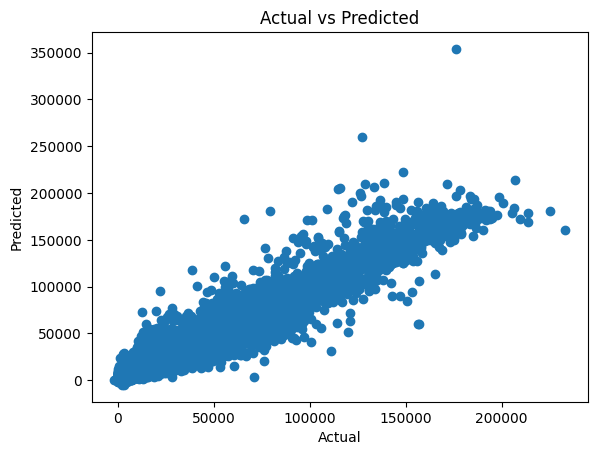

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_val, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()